# 01 - Inspect existing network inputs

**Purpose:** display the transmission routes and substation points aligned to the mapped routes, estimate how total demand might be shared between substations, and list the data still needed before outage calculations can run.

**Before running:**

- run `00_data_intake.ipynb` or the equivalent preparation command;
- use the repository `.venv` kernel;
- optionally place GridFinder and OSM line files under `data/0-incoming/energy/`.

**Expected inputs:**

- from `00_data_intake.ipynb`: `snapped_substations.parquet`, `transmission_routes.parquet`, `generation_register_template.csv`, and `substation_snap_distances.csv` under `data/1-processed/energy/collaborator`;
- optional reviewed generator data in `existing_generators.csv`, used only to label mapped generators with confirmed capacities where available;
- optional reviewed line data in `existing_lines.csv`, used only to label mapped routes where `source_route_id` links a reviewed line to supplied route geometry;
- optional demand-location proxies: `gridfinder/grid.gpkg` and `osm/distribution_lines.parquet` under `data/0-incoming/energy/`.

The transmission layer is vector data read from `PowerGrid.shp`. It is not traced from the reference PNG. The shapefile shows route geometry, but it does not provide a complete electrical line table with endpoint substations and power ratings. Every substation is snapped to its nearest route, but this notebook does not yet split routes into electrical line sections.


In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from mu_star_energy.distribution import build_service_weights
from mu_star_energy.paths import incoming_energy_dir, processed_energy_dir

COLLABORATOR_DIR = processed_energy_dir() / "collaborator"

substations = gpd.read_parquet(COLLABORATOR_DIR / "snapped_substations.parquet")
routes = gpd.read_parquet(COLLABORATOR_DIR / "transmission_routes.parquet")

generation_template = pd.read_csv(COLLABORATOR_DIR / "generation_register_template.csv")
existing_generators_path = COLLABORATOR_DIR / "existing_generators.csv"
generator_map_data = generation_template.copy()
if existing_generators_path.exists():
    reviewed_generators = pd.read_csv(existing_generators_path)
    if "generator_id" in reviewed_generators:
        reviewed_generators = reviewed_generators.drop_duplicates("generator_id").set_index("generator_id")
        if "capacity_mw" in reviewed_generators:
            reviewed_capacity = generator_map_data["generator_id"].map(reviewed_generators["capacity_mw"])
            generator_map_data["capacity_mw"] = reviewed_capacity.combine_first(
                generator_map_data["capacity_mw"]
            )

existing_lines_path = COLLABORATOR_DIR / "existing_lines.csv"
existing_lines = pd.read_csv(existing_lines_path) if existing_lines_path.exists() else pd.DataFrame()

def format_unique_values(values, unit):
    numeric = pd.to_numeric(values, errors="coerce").dropna().unique()
    if not len(numeric):
        return ""
    joined = "/".join(f"{value:g}" for value in sorted(numeric))
    return f"{joined} {unit}"


## Supplied transmission mapping

The map below plots the route geometry and the snapped substation points. It does not add connecting lines or split the routes yet.

The substation movements are reported in the intake notebook. Route labels show voltage and power-rating values only where those values are present in the route table or linked reviewed line data. The reference image `network_map_2025.png` has a legend for `66kV TRANSMISSION`, `132kV TRANSMISSION OPERATING AT 66kV`, and `SUBSTATION 66/22kV`; those labels are review context and are not automatically assigned to individual route rows. Most route records are unnamed, and the layer has no endpoint-substation, circuit-count, line-rating or operating-status fields.


,route ID,source name,voltage,line rating,mapped geometry length (km),geometry type
0,ROUTE_001,CEB 66 KV Line St Martin / Henrietta,66 kV,,149.678438,MultiLineString
1,ROUTE_002,unnamed,,,154.919516,MultiLineString
2,ROUTE_003,unnamed,,,4.214733,LineString
3,ROUTE_004,unnamed,,,2.826148,MultiLineString
4,ROUTE_005,unnamed,,,1.739230,LineString
5,ROUTE_006,unnamed,,,6.450767,MultiLineString


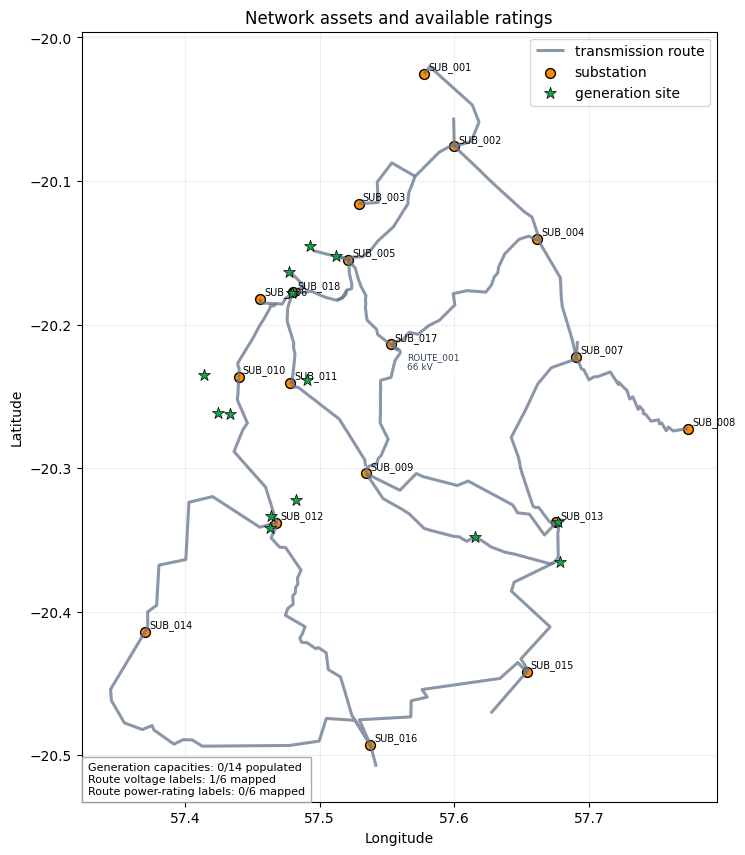

In [6]:
routes_for_plot = routes.copy()
if "v_nom_kv" not in routes_for_plot:
    routes_for_plot["v_nom_kv"] = pd.NA
if "capacity_mw" not in routes_for_plot:
    routes_for_plot["capacity_mw"] = pd.NA

routes_for_plot["voltage_label"] = routes_for_plot["v_nom_kv"].apply(
    lambda value: f"{value:g} kV" if pd.notna(value) else ""
)
routes_for_plot["rating_label"] = routes_for_plot["capacity_mw"].apply(
    lambda value: f"{value:g} MW" if pd.notna(value) else ""
)
line_ratings_mapped = 0
if not existing_lines.empty and "source_route_id" in existing_lines:
    for route_id, group in existing_lines.groupby("source_route_id"):
        route_mask = routes_for_plot["route_id"].eq(str(route_id))
        voltage_label = format_unique_values(group.get("v_nom_kv", pd.Series(dtype=float)), "kV")
        rating_label = format_unique_values(group.get("s_nom_mva", pd.Series(dtype=float)), "MVA")
        if voltage_label:
            routes_for_plot.loc[route_mask, "voltage_label"] = voltage_label
        if rating_label:
            routes_for_plot.loc[route_mask, "rating_label"] = rating_label
            line_ratings_mapped += int(route_mask.any())

route_summary = routes_for_plot.assign(geometry_type=routes_for_plot.geometry.geom_type)[
    [
        "route_id",
        "name",
        "voltage_label",
        "rating_label",
        "length_km",
        "geometry_type",
    ]
]
display(route_summary.rename(columns={
    "route_id": "route ID",
    "name": "source name",
    "voltage_label": "voltage",
    "rating_label": "line rating",
    "length_km": "mapped geometry length (km)",
    "geometry_type": "geometry type",
}))

fig, ax = plt.subplots(figsize=(10, 10))
routes_for_plot.plot(
    ax=ax,
    color="#64748b",
    linewidth=2.2,
    alpha=0.75,
    label="transmission route",
)
for _, row in routes_for_plot.iterrows():
    rating_parts = []
    if row["voltage_label"]:
        rating_parts.append(row["voltage_label"])
    if row["rating_label"]:
        rating_parts.append(row["rating_label"])
    if not rating_parts:
        continue
    label_point = row.geometry.representative_point()
    ax.annotate(
        f"{row['route_id']}\n" + "\n".join(rating_parts),
        (label_point.x, label_point.y),
        xytext=(5, -12),
        textcoords="offset points",
        fontsize=6.5,
        color="#334155",
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8, "pad": 1},
    )
substations.plot(
    ax=ax,
    color="#ff8c00",
    edgecolor="black",
    markersize=50,
    label="substation",
)
for _, row in substations.iterrows():
    ax.annotate(
        row["bus_id"],
        (row.geometry.x, row.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=7,
    )
for generator_index, (_, row) in enumerate(generator_map_data.iterrows()):
    ax.scatter(
        row["lon"],
        row["lat"],
        marker="*",
        s=80,
        color="#16a34a",
        edgecolors="black",
        linewidths=0.5,
        zorder=7,
        label="generation site" if generator_index == 0 else None,
    )
    if pd.notna(row["capacity_mw"]):
        ax.annotate(
            f"{row['capacity_mw']:g} MW_e",
            (row["lon"], row["lat"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=6.5,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1},
            zorder=8,
        )
capacity_count = int(generator_map_data["capacity_mw"].notna().sum())
status_lines = [
    f"Generation capacities: {capacity_count}/{len(generator_map_data)} populated",
    f"Route voltage labels: {int(routes_for_plot['voltage_label'].astype(bool).sum())}/{len(routes_for_plot)} mapped",
    f"Route power-rating labels: {int(routes_for_plot['rating_label'].astype(bool).sum())}/{len(routes_for_plot)} mapped",
]
if not existing_lines.empty and "source_route_id" not in existing_lines:
    status_lines.append("Add source_route_id to existing_lines.csv for map labels")
ax.text(
    0.01,
    0.01,
    "\n".join(status_lines),
    transform=ax.transAxes,
    fontsize=8,
    bbox={"facecolor": "white", "edgecolor": "#9ca3af", "alpha": 0.9},
)
ax.set_title("Network assets and available ratings")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(alpha=0.2)
ax.legend()
plt.show()


## Estimating each substation's share of demand

OSM and GridFinder lines are optional. When available, the code assigns each mapped distribution-line section to the nearest transmission substation. The amount of mapped line near each substation is then used as a rough guide to its share of total demand.

This estimate is only for locating customers and demand. GridFinder routes are estimates and are not added to the electrical network calculation.


In [7]:
def optional_line_layer(path):
    if not path.exists():
        return None
    return gpd.read_parquet(path) if path.suffix == ".parquet" else gpd.read_file(path)


gridfinder_path = incoming_energy_dir() / "gridfinder" / "grid.gpkg"
osm_path = incoming_energy_dir() / "osm" / "distribution_lines.parquet"
service_weights = build_service_weights(
    substations,
    gridfinder_lines=optional_line_layer(gridfinder_path),
    osm_distribution_lines=optional_line_layer(osm_path),
)
service_weights.to_csv(COLLABORATOR_DIR / "service_weights.csv", index=False)
display(service_weights.rename(columns={
    "bus_id": "substation ID",
    "gridfinder_km": "GridFinder line length (km)",
    "osm_km": "OSM line length (km)",
    "service_weight": "share of total demand",
    "method": "method used",
}))


,substation ID,GridFinder line length (km),OSM line length (km),share of total demand,method used
0,SUB_001,0.0,0.0,0.055556,equal_no_distribution_proxy
1,SUB_002,0.0,0.0,0.055556,equal_no_distribution_proxy
2,SUB_003,0.0,0.0,0.055556,equal_no_distribution_proxy
3,SUB_004,0.0,0.0,0.055556,equal_no_distribution_proxy
4,SUB_005,0.0,0.0,0.055556,equal_no_distribution_proxy
5,SUB_006,0.0,0.0,0.055556,equal_no_distribution_proxy
6,SUB_007,0.0,0.0,0.055556,equal_no_distribution_proxy
7,SUB_008,0.0,0.0,0.055556,equal_no_distribution_proxy
8,SUB_009,0.0,0.0,0.055556,equal_no_distribution_proxy
9,SUB_010,0.0,0.0,0.055556,equal_no_distribution_proxy


## Information needed before the model can run

The operational model requires a separate `existing_lines.csv`. Each row must state the line ID, endpoint substations, voltage, length and maximum power. This file is not generated from the mapped route geometry.

For demand over time, the model accepts either one Mauritius-wide `demand_mw` series or one column per substation. Regular half-hourly, hourly and three-hourly data are supported. The current automated workflow only checks that `demand_profile.csv` exists; reading the file and launching outage cases still needs to be added.


In [8]:
generator_register = generator_map_data
required_line_columns = {"line_id", "bus0", "bus1", "v_nom_kv", "length_km", "s_nom_mva"}
line_columns_complete = required_line_columns.issubset(existing_lines.columns)
line_values_complete = bool(
    line_columns_complete
    and len(existing_lines)
    and existing_lines[list(required_line_columns)].notna().all().all()
)

readiness = pd.Series({
    "vector route records": len(routes),
    "existing electrical line table present": int(existing_lines_path.exists()),
    "existing electrical lines listed": len(existing_lines),
    "line endpoint and rating fields complete": int(line_values_complete),
    "power stations with maximum output": int(generator_register["capacity_mw"].notna().sum()),
    "total power stations requiring maximum output": len(generator_register),
    "power stations with running cost": int(generator_register["marginal_cost"].notna().sum()),
    "total power stations requiring running cost": len(generator_register),
    "power stations with connected substation": int(generator_register["bus_id"].notna().sum()),
    "total power stations requiring a substation": len(generator_register),
    "demand-over-time file present": int((COLLABORATOR_DIR / "demand_profile.csv").exists()),
    "method used to share demand": service_weights["method"].iloc[0] if len(service_weights) else "none",
})
display(readiness.to_frame("value"))


,value
vector route records,6
existing electrical line table present,0
existing electrical lines listed,0
line endpoint and rating fields complete,0
power stations with maximum output,0
total power stations requiring maximum output,14
power stations with running cost,0
total power stations requiring running cost,14
power stations with connected substation,0
total power stations requiring a substation,14


## How an outage is described

After the input checks are complete, mu-star supplies a table such as:

| `component` | `asset_id` | `available_fraction` |
|---|---|---:|
| Line | LINE_004 | 0.0 |
| Generator | Fort_George_1 | 0.4 |
| Bus | SUB_008 | 0.0 |

`component` identifies a line, power station (`Generator`) or substation (`Bus`, the PyPSA term). `available_fraction` is the usable share: 1 means fully available, 0 means completely unavailable and 0.4 means 40% available.

`EnergyModel.simulate(network, disruptions)` copies the supplied fixed-capacity model, applies these reductions, recalculates electricity production and reports unmet demand, the share of demand served and operating cost. The separate damage work determines the available fraction supplied to this model.
